# Úkol č. 2 - regrese

* Termíny jsou uvedeny na [courses.fit.cvut.cz/BI-ML1/homeworks/index.html](https://courses.fit.cvut.cz/BI-ML1/homeworks/index.html).
* Pokud odevzdáte úkol po prvním termínu, ale před nejzazším termínem, budete penalizování -12 body, pozdější odevzdání je bez bodu.
* V rámci tohoto úkolu se musíte vypořádat s regresní úlohou, s příznaky různých typů a s chybějícími hodnotami.
* Před tím, než na nich postavíte predikční model, je třeba je nějakým způsobem převést do číselné reprezentace.
    
> **Úkoly jsou zadány tak, aby Vám daly prostor pro invenci. Vymyslet _jak přesně_ budete úkol řešit, je důležitou součástí zadání a originalita či nápaditost bude také hodnocena!**

Využívejte buňky typu `Markdown` k vysvětlování Vašeho postupu. Za nepřehlednost budeme strhávat body.

## Zdroj dat

Budeme se zabývat predikcí délky dožití v různých zemích a letech.
K dispozici máte trénovací data v souboru `data.csv` a data na vyhodnocení v souboru `evaluation.csv`.

#### Seznam příznaků:

* Year - Rok
* Status - Status rozvinuté nebo rozvojové země
* Life expectancy - Délka dožití v letech - **cílová proměnná, kterou budete predikovat**
* Adult Mortality - Úmrtnost dospělých bez ohledu na pohlaví (pravděpodobnost, že osoby, které dosáhly věku 15 let, zemřou před dosažením věku 60 let (uvedeno na 1 000 osob)).
* infant deaths - počet zemřelých kojenců na 1000 obyvatel
* Alcohol - Alkohol, zaznamenaná spotřeba na obyvatele (15+) (v litrech čistého alkoholu)
* percentage expenditure - Výdaje na zdravotnictví v procentech hrubého domácího produktu na obyvatele (%)
* Hepatitis B - pokrytí očkováním proti hepatitidě B (HepB) u dětí ve věku 1 roku (%)
* Measles - Spalničky - počet hlášených případů na 1000 obyvatel
* BMI - průměrný index tělesné hmotnosti celé populace
* under-five deaths - počet úmrtí dětí do pěti let na 1000 obyvatel
* Polio - proočkovanost proti dětské obrně (Pol3) u dětí ve věku 1 roku (%)
* Total expenditure - Výdaje vládních institucí na zdravotnictví jako procento celkových vládních výdajů (%)
* Diphtheria - pokrytí očkováním proti záškrtu, tetanu a černému kašli (DTP3) u jednoletých dětí (%)
* HIV/AIDS - počet úmrtí na 1 000 živě narozených dětí na HIV/AIDS (0-4 roky)
* GDP - hrubý domácí produkt na obyvatele (v USD)
* Population - počet obyvatel země
* thinness 1-19 years - podíl dětí ve věku 10-19 let s indexem tělesné hmotnosti (BMI) menším než 2 směrodatné odchylky pod mediánem (%)
* thinness 5-9 years - podíl dětí ve věku 5-9 let s indexem tělesné hmotnosti (BMI) menším než 2 směrodatné odchylky pod mediánem (%)
* Income composition of resources - Index lidského rozvoje z hlediska příjmového složení zdrojů (index v rozmezí 0 až 1)
* Schooling - počet let školní docházky (roky)


## Pokyny k vypracování

**Body zadání**, za jejichž (poctivé) vypracování získáte **25 bodů**: 
  * V notebooku načtěte data ze souboru `data.csv`. Vhodným způsobem si je rozdělte na podmnožiny, které Vám poslouží pro trénování (trénovací), porovnávání modelů (validační) a následnou predikci výkonnosti finálního modelu (testovací).
    
  * Proveďte základní předzpracování dat:
    * Projděte si jednotlivé příznaky a transformujte je do vhodné podoby pro použití ve vybraném regresním modelu.
    * Nějakým způsobem (klidně triviálním) se vypořádejte s chybějícími hodnotami. _Pozor na metodické chyby!_
    * Můžete využívat i vizualizace. Vše stručně ale náležitě komentujte.
<br /><br />
  * Vytvořte **vlastní implementaci náhodného lesa**. Použijte k tomu níže předpřipravenou kostru.
  
  * Na připravená data postupně aplikujte Vaši předchozí implementaci modelu náhodného lesa, dále jeden z modelů **lineární regrese** nebo **hřebenové regrese**, a alespoň jeden další model podle Vašeho uvážení, přičemž pro každý z těchto modelů přiměřeně:
    * Okomentujte vhodnost daného modelu pro daný typ úlohy.
    * Experimentujte s normalizací (standardizace/min-max), pokud pro daný model očekáváte její příznivý vliv.
    * Vyberte si hlavní hyperparametry k ladění a najděte jejich nejlepší hodnoty (vzhledem k RMSE).
    * Pro model s nejlepšími hodnotami hyperparametrů na validační množině určete jeho chybu pomocí RMSE a MAE.
    * Získané výsledky vždy řádně okomentujte.
<br /><br />
  * Ze všech zkoušených možností v předchozím kroku vyberte finální model a správně odhadněte, jakou chybu (RMSE) můžete očekávat na nových datech, která jste doposud neměli k dispozici. _Pozor na metodické chyby!_
    
  * Nakonec načtěte vyhodnocovací data ze souboru `evaluation.csv`. Pomocí finálního modelu napočítejte predikce pro tyto data. Vytvořte soubor `results.csv`, ve kterém získané predikce uložíte do sloupce **Life expectancy** a jednotlivé body identifikujete pomocí sloupců **Country** a **Year** (dodržte názvy sloupců!). Tento soubor též odevzdejte (uložte do repozitáře vedle notebooku).

  * Ukázka, jak by mělo vypadat prvních několik řádků souboru `results.csv` (obecně s jinými hodnotami Life expectancy):
  
```
Country,Year,Life expectancy
Peru,2012,71.4
Peru,2013,72.6
...
```


## Poznámky k odevzdání

  * Řiďte se pokyny ze stránky https://courses.fit.cvut.cz/BI-ML1/homeworks/index.html.

# Řešení 🎯

In [1]:
# imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, ParameterGrid
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
data = pd.read_csv('data.csv')

ydata = data['Life expectancy']
Xdata = data.drop('Life expectancy', axis=1)

seed = 42
# rozdělujeme data na trénovací, validační a testovací, poměr 60:20:20
Xtrain, Xtest, ytrain, ytest = train_test_split(Xdata, ydata, test_size=0.20, random_state=seed) 
Xtrain, Xval, ytrain, yval = train_test_split(Xtrain, ytrain, test_size=0.25, random_state=seed)

##  Předzpracování dat 🧹💨

Nejprve se podíváme na to, s jakými daty vlastně pracujeme.

Můžeme si všimnout chybějících hodnot v některých sloupcích a také dvou nenumerických příznaků, které by mohly být problematické pro modely, které budeme chtít vytvářet.

In [3]:
Xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1630 entries, 2658 to 1618
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          1630 non-null   object 
 1   Year                             1630 non-null   int64  
 2   Status                           1630 non-null   object 
 3   Adult Mortality                  1630 non-null   float64
 4   infant deaths                    1630 non-null   int64  
 5   Alcohol                          1536 non-null   float64
 6   percentage expenditure           1630 non-null   float64
 7   Hepatitis B                      1303 non-null   float64
 8   Measles                          1630 non-null   int64  
 9   BMI                              1614 non-null   float64
 10  under-five deaths                1630 non-null   int64  
 11  Polio                            1616 non-null   float64
 12  Total expenditure     

In [4]:
for df in [Xtest, Xval, Xtrain]:
    for col in df.select_dtypes('object').columns:
        df[col] = df[col].astype('category')

display(Xtrain.Status.unique())

['Developing', 'Developed']
Categories (2, object): ['Developed', 'Developing']

Jak vidíme, jeden z těchto problematických příznaků, Status, nabývá pouze dvou hodnot a lehce ho tedy přetypujeme na binární:

In [5]:
for df in [Xtest, Xval, Xtrain]:
    df['Developed'] = df['Status'].map({'Developed': 1, 'Developing': 0}).astype(int)
    df.drop('Status', axis=1, inplace=True)

for df in [Xtest, Xval, Xtrain]:
    df.drop(['Country', 'Year'], axis=1, inplace=True)

Zároveň jsme smazali i příznaky Country a Year, s nimiž by se těžko pracovalo (obzvlášť s Country jakožto nominálním kategorickým typem, který nabývá mnoha unikátních hodnot) a mohli by do predikcí vnášet zaujatost. 

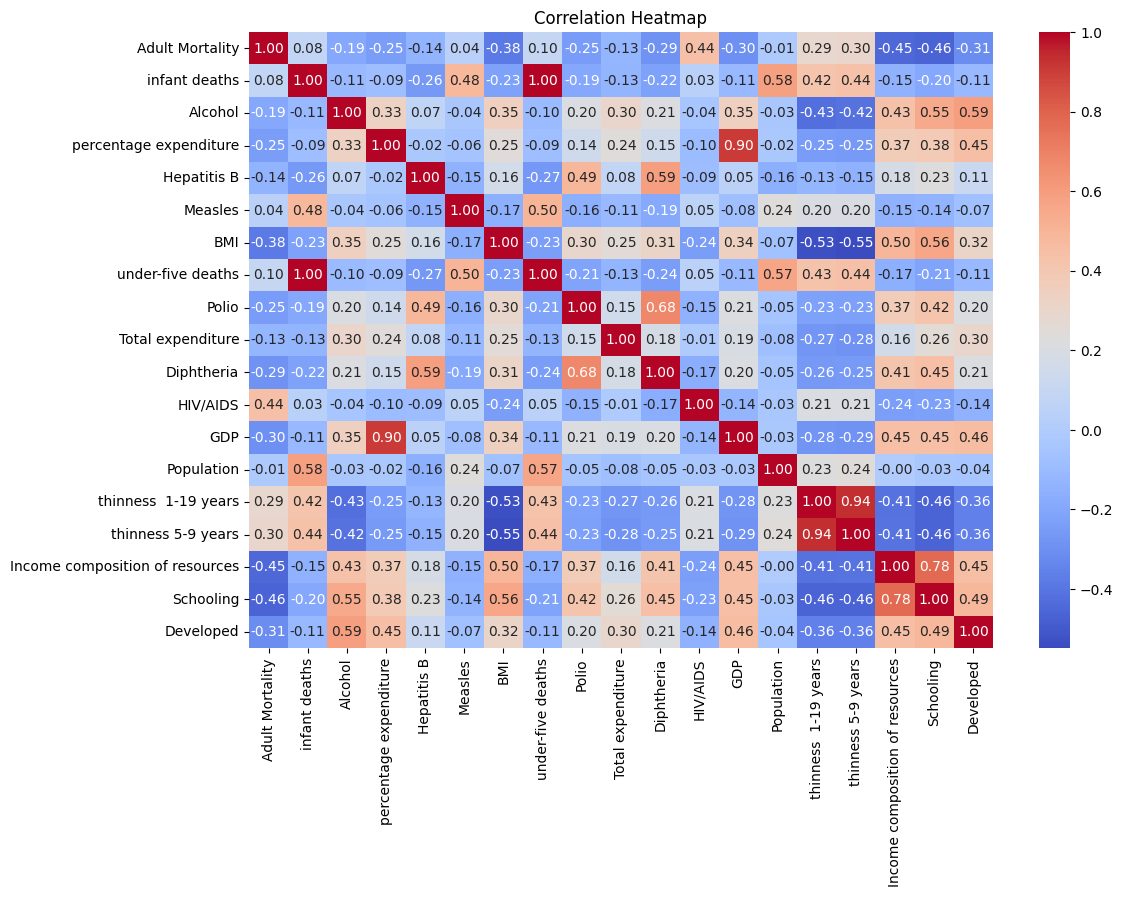

In [6]:
correlation_matrix = Xtrain.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
plt.show()

Protože budeme využívat modelu lineární regrese, je v našem zájmu ošetřit kolineární příznaky. Z korelační matice vidíme, že některé páry příznaků jsou v podstatě kolineární a tedy vždy jeden z nich smažeme:

In [7]:
for df in [Xtest, Xval, Xtrain]:
    df.drop(['under-five deaths', 'thinness 5-9 years', 'percentage expenditure'], axis=1, inplace=True)

Poslední co nám zbývá, je pak již jen ošetření chybějících hodnot, které jednoduše nastavíme na -1 a necháme modely, aby s nimi takto samy počítaly:

In [8]:
for df in [Xtrain, Xval, Xtest]:
    df.fillna(-1, inplace=True)

In [9]:
Xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1630 entries, 2658 to 1618
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Adult Mortality                  1630 non-null   float64
 1   infant deaths                    1630 non-null   int64  
 2   Alcohol                          1630 non-null   float64
 3   Hepatitis B                      1630 non-null   float64
 4   Measles                          1630 non-null   int64  
 5   BMI                              1630 non-null   float64
 6   Polio                            1630 non-null   float64
 7   Total expenditure                1630 non-null   float64
 8   Diphtheria                       1630 non-null   float64
 9   HIV/AIDS                         1630 non-null   float64
 10  GDP                              1630 non-null   float64
 11  Population                       1630 non-null   float64
 12  thinness  1-19 years  

## Náhodný les 🌳🌳

Regresní Random Forest je vhodný pro predikci věku dožití v různých zemích a letech, protože je schopen zachytit nelineární vztahy mezi proměnnými, které mohou ovlivnit věk dožití jako jsou socioekonomické faktory, zdravotní péče nebo školství. Díky schopnosti pracovat s velkými a různorodými daty a automaticky zohledňovat vzájemné vztahy mezi příznaky je tento typ modelu více odolný vůči chybám v datech a šumům, což je ideální pro složitější predikce, jako máme zde.

In [10]:
# vlastní implementace:
from sklearn.tree import DecisionTreeRegressor

class CustomRandomForest:
    """
    Třída Vašeho modelu
    Bude se jednat o model náhodného lesa, kde podmodely tvoří rozhodovací stromy pro regresi.
    Pro podmodely můžete použít implementaci DecisionTreeRegressor ze sklearn.
    """
    def __init__(self, n_estimators, max_samples, max_depth, **kwargs):
        """
        Konstruktor modelu
        Základní hyperparametery:
            n_estimators - počet podmodelů - rozhodovacích stromů.
            max_samples - vyberte si, zda tento parametr bude označovat relativní počet bodů (tj. číslo mezi 0 a 1) 
                          nebo absolutní počet bodů (tj. číslo mezi 1 a velikostí trénovací množiny), 
                          které budou pro každý podmodel rozhodovacího stromu náhodně vybrány z trénovací množiny (bootstrap) a použity k jeho trénování.
            max_depth - maximální hloubka každého z podmodelů rozhodovacího stromu.
            kwargs - (volitelně) případné další hyperparametry, které pošlete do podmodelů rozhodovacího stromu
        """
        self.n_estimators = n_estimators
        self.max_samples = max_samples
        self.max_depth = max_depth
        self.kwargs = kwargs
        self.trees = []
        
        
    def fit(self, X, y):
        """
        Natrénování modelu. Trénovací data jsou v argumentech X a y.
        Pro trénování podmodelů používejte bootstraping a velikost samplovaného vzorku vezměte z hyperparametru max_samples_fraction
        """
        self.trees = []
        # fit each tree
        for _ in range(self.n_estimators):
            tree = DecisionTreeRegressor(max_depth=self.max_depth, **self.kwargs)
            X_sample, y_sample = self._bootstrap_samples(X, y)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
        return self
            

    # create max_samples number of indices to randomly fit the tress with
    def _bootstrap_samples(self, X, y):
        indices = np.random.choice(X.index, size=self.max_samples, replace=True)
        return X.loc[indices], y.loc[indices]

    
    def predict(self, X):
        """
        Predikce y v zadaných bodech X
        """
        # predict each entry with the mean decision of all the trees in the forest
        predictions = np.zeros((self.n_estimators, X.shape[0]))
        for i, tree in enumerate(self.trees):
            predictions[i] = tree.predict(X)
        
        ypredicted = np.mean(predictions, axis=0)
        return ypredicted


In [11]:
forest = CustomRandomForest(n_estimators=20, max_samples=50, max_depth=8)
forest.fit(Xtrain, ytrain)

train_predictions = forest.predict(Xtrain)
val_predictions = forest.predict(Xval)

train_rmse = np.sqrt(mean_squared_error(ytrain, train_predictions))
val_rmse = np.sqrt(mean_squared_error(yval, val_predictions))

print(f'RMSE (train): {train_rmse:.6f}')
print(f'RMSE (validation): {val_rmse:.6f}')

RMSE (train): 3.349709
RMSE (validation): 3.343062


In [12]:
# jako hyperparametry jsme zvolili pouze ty přímo předepsané v deklaraci naší implementace Random Forest z důvodu nízké výpočetní kapacity
param_grid = {
    'n_estimators': range(25, 201, 25),
    'max_samples': range(30, 1631, 200),
    'max_depth': range(3, 21, 2)
}

param_comb = ParameterGrid(param_grid)

val_rmse = []
train_rmse = []

# pro každou variantu hyperparametrů zjistíme, jak dobře si vede na trénovacím a validačním datasetu
for params in param_comb:
    forest = CustomRandomForest(**params).fit(Xtrain, ytrain)
    train_rmse.append(np.sqrt(mean_squared_error(ytrain, forest.predict(Xtrain))))
    val_rmse.append(np.sqrt(mean_squared_error(yval, forest.predict(Xval))))

# minimalizujeme RMSE
best_index = np.argmin(val_rmse)
best_params = param_comb[best_index]
print(f"Best params: {best_params} with validation RMSE {val_rmse[best_index]:.4f}.")
print(f"Train RMSE for the best parameters: {train_rmse[best_index]:.4f}")

Best params: {'n_estimators': 75, 'max_samples': 1630, 'max_depth': 15} with validation RMSE 1.8265.
Train RMSE for the best parameters: 0.7605


In [13]:
# podle výsledků na validační množině jsme vybrali nejlepší sadu hyperparametrů, s níž natrénujeme finální model
bestRF = CustomRandomForest(**best_params).fit(Xtrain, ytrain)
y_pred = bestRF.predict(Xval)
rmse = np.sqrt(mean_squared_error(yval, y_pred))
print(f"Final Random Forest model validation RMSE: {rmse:.4f}")
mae = mean_absolute_error(yval, y_pred)
print(f"Final Random Forest model validation MAE: {mae:.4f}")

Final Random Forest model validation RMSE: 1.8573
Final Random Forest model validation MAE: 1.2119


## Lineární regrese 📈

Lineární regrese je vhodná pro predikci věku dožití, protože se snaží jednodušše modelovat vztahy mezi faktory, které mohou věk dožití ovlivnit, jako je například zdravotní péče nebo ekonomická situace. Předpokládá ale, že změny v těchto faktorech mají lineární vliv na věk dožití (každý příznak přispívá k výsledku stejným způsobem). Je výhodou, že je snadný na použití a interpretaci, ale může mít problém s nelineárními vztahy mezi faktory a zároveň je citlivý na kolinearitu příznaků, kterou jsme se již pokusili ošetřit během přípravy dat.

In [14]:
# využijeme implementaci od scikitu, která však nemá parametry, které bychom mohli ladit
# u lineární regrese nebudeme benefitovat ani z pokusů o normalizaci, tedy pouze model naučíme a jsme hotovi
from sklearn.linear_model import LinearRegression

bestLR = LinearRegression().fit(Xtrain, ytrain)
y_pred = bestLR.predict(Xval)
rmse = np.sqrt(mean_squared_error(yval, y_pred))
print(f"Final Linear Regression model validation RMSE: {rmse:.4f}")
mae = mean_absolute_error(yval, y_pred)
print(f"Final Linear Regression model validation MAE: {mae:.4f}")

Final Linear Regression model validation RMSE: 4.3320
Final Linear Regression model validation MAE: 3.3331


##  Rozhodovací strom 🌳

Tento typ modelu je vhodný pro predikci věku dožití, protože dokáže snadno zachytit složité a nelineární vztahy mezi faktory, které ovlivňují věk dožití, podobně jako Random Forest, který se o něj opírá. Je flexibilní a dokáže pracovat s různými typy dat, ale na rozdíl od Random Forest je více náchylný na přetrénování, na což si musíme dát pozor při jeho trénování.

In [15]:
# vybíráme si hyperparametry, které dobře preventují přeučení modelu
param_grid = { 
    'criterion': ['squared_error', 'absolute_error'],
    'max_depth': range(1,20),
    'max_features': range(1,7),
    'min_samples_leaf': range(1,25),
}
param_comb = ParameterGrid(param_grid)

In [16]:
# pro každou variantu hyperparametrů zjistíme, jak dobře si vede na trénovacím a validačním datasetu
val_rmse = []
train_rmse = []
for params in param_comb:
    tree = DecisionTreeRegressor(max_depth=params['max_depth'], criterion=params['criterion'], max_features=params['max_features'], min_samples_leaf=params['min_samples_leaf'], random_state = seed)
    tree.fit(Xtrain, ytrain)
    train_rmse.append(np.sqrt(mean_squared_error(ytrain, tree.predict(Xtrain))))
    val_rmse.append(np.sqrt(mean_squared_error(yval, tree.predict(Xval))))

In [17]:
# podle výsledků na validační množině opět vybereme nejlepší sadu hyperparametrů, s níž natrénujeme finální model
best_index = np.argmin(val_rmse)
best_paramsT = param_comb[best_index]
print(f"Best params: {best_paramsT} with validation RMSE {val_rmse[best_index]:.4f}.")
print(f"Train RMSE for the best parameters: {train_rmse[best_index]:.4f}")

Best params: {'min_samples_leaf': 4, 'max_features': 6, 'max_depth': 11, 'criterion': 'squared_error'} with validation RMSE 2.4389.
Train RMSE for the best parameters: 1.4528


In [18]:
bestDTR = DecisionTreeRegressor(**best_paramsT, random_state = seed).fit(Xtrain, ytrain)
y_pred = bestDTR.predict(Xval)
rmse = np.sqrt(mean_squared_error(yval, y_pred))
print(f"Final Random Forest model validation RMSE: {rmse:.4f}")
mae = mean_absolute_error(yval, y_pred)
print(f"Final Random Forest model validation MAE: {mae:.4f}")

Final Random Forest model validation RMSE: 2.4389
Final Random Forest model validation MAE: 1.6383


## Výsledky 🏆

Zdaleka nejlépe, co se týče výsledné RMSE je na tom tedy Random Forest, následován Decison Tree a nakonec Linear Regression modelem.

Jako vítězný model tedy zvolíme Random Forest, s nímž uděláme predikce evaluačních dat a odhadneme jeho RMSE na nových datech pomocí testovací množiny, kterou jsme si na začátku vyhradili.

In [19]:
print("Final Random Forest model hyperparameters:", best_params)
print('RMSE (test): {0:.4f}'.format(np.sqrt(mean_squared_error(ytest, bestRF.predict(Xtest)))))

Final Random Forest model hyperparameters: {'n_estimators': 75, 'max_samples': 1630, 'max_depth': 15}
RMSE (test): 1.6591


In [20]:
eval_data = pd.read_csv('evaluation.csv')

# dataset zpracujeme stejně jako původní
for col in eval_data.select_dtypes('object').columns:
        eval_data[col] = eval_data[col].astype('category')

cols_to_drop = ['Status', 'under-five deaths', 'thinness 5-9 years', 'percentage expenditure']
eval_data['Developed'] = eval_data['Status'].map({'Developed': 1, 'Developing': 0}).astype(int)
eval_data.drop(cols_to_drop, axis=1, inplace=True)

nan_cols = eval_data.select_dtypes(exclude='category').columns
eval_data[nan_cols] = eval_data[nan_cols].fillna(-1)

eval_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   Country                          210 non-null    category
 1   Year                             210 non-null    int64   
 2   Adult Mortality                  210 non-null    float64 
 3   infant deaths                    210 non-null    int64   
 4   Alcohol                          210 non-null    float64 
 5   Hepatitis B                      210 non-null    float64 
 6   Measles                          210 non-null    int64   
 7   BMI                              210 non-null    float64 
 8   Polio                            210 non-null    float64 
 9   Total expenditure                210 non-null    float64 
 10  Diphtheria                       210 non-null    float64 
 11  HIV/AIDS                         210 non-null    float64 
 12  GDP     

In [21]:
predictions = bestRF.predict(eval_data.drop(columns=['Country', 'Year']))
results = pd.DataFrame({'Country': eval_data['Country'], 'Year': eval_data['Year'], 'Life expectancy': predictions})

results.to_csv('results.csv', index=False)